In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, regularised_score
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation, cross_validated_parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import train_val_split, run_inference_algorithm_with_burn_in


from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler
from scipy import stats

jax.config.update("jax_enable_x64", True)

In [2]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset("machine", split=1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(example.x_train)
y_train = scaler_y.fit_transform(example.y_train)

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [6]:
x_train.shape

(168, 7)

In [7]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
lengthscale = gpx.parameters.SigmoidBounded(
    jnp.sqrt(D) * jnp.ones((D,)), low=1.0e-3, high=1.0e3
)
kernel = gpx.kernels.RBF(lengthscale=lengthscale, variance=px.NonTrainable(jnp.array(1.0)))

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n, obs_stddev=jnp.sqrt(0.01))
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
)

gp_latent_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP NLPD:", nlpd_gp(y_train, gp_predictive_mean, gp_predictive_std))
print("GP sigma", px.unwrap(gp_sigma))

Optimization terminated successfully.
         Current function value: 97.537859
         Iterations: 64
         Function evaluations: 73
         Gradient evaluations: 73
GP NLPD: 0.42689747214025436
GP sigma 0.3803664719124478


In [8]:
gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

GP NLPD: 0.4772397022029885


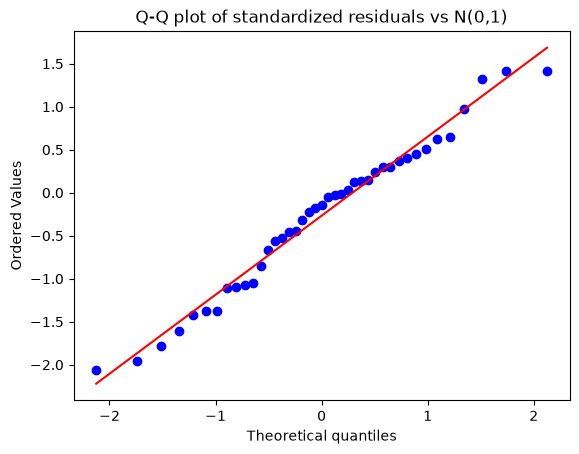

Shapiro-Wilk: 0.48451662284617447
Kolmogorov-Smirnov: 0.21207140060832252


In [9]:
gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

residuals = (y_test.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

ks_stat, ks_pvalue = stats.kstest(residuals, "norm")

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)
print("Kolmogorov-Smirnov:", ks_pvalue)

In [82]:
M = x_train.shape[0]
J = 1

initial_sigma = px.unwrap(gp_sigma)
sigma = gpx.parameters.SigmoidBounded(initial_sigma, low=0.06, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=None,
    step_size=1e-4,
    sigma=sigma,
    alpha=1.0,
)

In [83]:
# adaptation = cross_validated_parameter_adaptation(
#     ula,
#     pro_logdensity_fn,
#     pro_params,
#     x_full=x_train,
#     y_full=y_train,
#     initial_kernel=gp_kernel,
#     num_folds=1,
#     val_fraction=0.5,
#     num_particles=J,
#     num_steps=10000,
#     warmup_steps=1000,
#     sigma_adapt_every=10,
#     kernel_adapt_every=-1,
#     objective_fn=pro_logdensity_fn,
#     sigma_optimizer=ox.adam(1e-1),
#     kernel_optimizer=ox.adam(1e-2),
#     progress_bar=True,
#     rng_key=key
# ) 

In [84]:
# adapted_kernel = adaptation.kernel
# adapted_sigma = adaptation.sigma

adapted_kernel = kernel
adapted_sigma = initial_sigma

k = adapted_kernel.gram(x_train).as_matrix()
basis_full = jnp.linalg.cholesky(k + 1e-6 * jnp.eye(k.shape[0]))

pro_params = pro_params._replace(basis=basis_full, sigma=adapted_sigma, step_size=0.0001, alpha=1.0)

adapted_sigma

Array(0.38036647, dtype=float64)

In [85]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)
num_steps = 30000

key, pos_key = jr.split(key)
initial_position = jr.normal(pos_key, (M, J))

key, sample_key = jr.split(key)
_, (states, info) = run_inference_algorithm_with_burn_in(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    initial_position=initial_position,
    num_steps=num_steps,
    burn_ratio=0.01,
    progress_bar=True,
)

Burning in for 300 steps...


<div><progress max="300" value="300"></progress> 100.00% [300/300 00:00&lt;?]</div>

Sampling for 29700 steps...


<div><progress max="29700" value="29700"></progress> 100.00% [29700/29700 00:00&lt;?]</div>

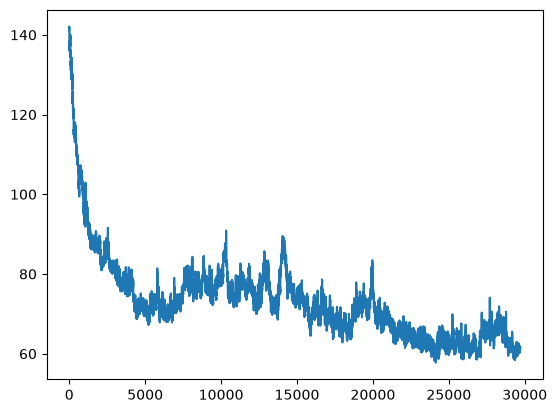

In [86]:
plt.plot(-info.score)
plt.show()

In [87]:
particles = states.position[25000:][::50]

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_train, pro_params
)

print("PRO NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))

PRO NLPD: 0.35821278143421315


In [88]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))
print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))

GP NLPD: 0.4772397022029885
PRO NLPD: 0.6329711814655813
